In [1]:
import pandas as pd

dataset = pd.read_csv("dataset.csv")
test_data = pd.read_csv("test_data.csv")

In [ ]:
dataset.to_csv("dataset.csv", index=False)
dataset.head()

,distance,distance_mod,comparison_distance
0,0.453751,0.325210,0.431952
1,0.377880,0.321822,0.465866
2,0.499194,0.417549,0.533753
3,0.384869,0.336282,0.429921
4,0.462745,0.302336,0.538365


In [ ]:
test_data.to_csv("test_data.csv", index=False)
test_data.head()

,distance,distance_mod
0,0.300013,0.387037
1,0.339069,0.325649
2,0.331622,0.317612
3,0.331744,0.359667
4,0.329942,0.477657


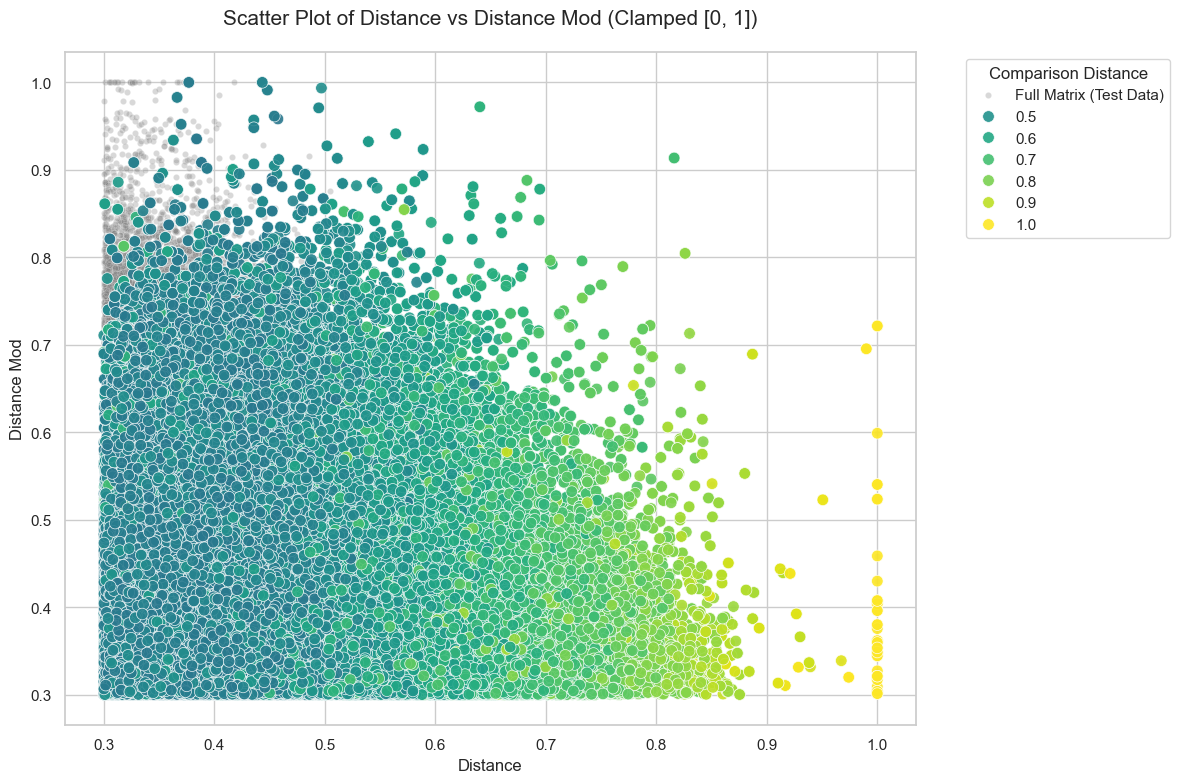

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clamp the values between 0 and 1.0
# .clip(0, 1.0) ensures any value < 0 becomes 0, and any value > 1 becomes 1
dataset_clamped = dataset.clip(0, 1.0)
test_clamped = test_data.clip(0, 1.0)

# 2. Setup the aesthetics
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Plot Test Data (Full Matrix) as a background layer
sns.scatterplot(
    data=test_clamped, 
    x='distance', 
    y='distance_mod', 
    alpha=0.3, 
    color='gray', 
    label='Full Matrix (Test Data)',
    s=20
)

# 4. Plot the Dataset with comparison_distance as a color scale
sns.scatterplot(
    data=dataset_clamped, 
    x='distance', 
    y='distance_mod', 
    hue='comparison_distance',  
    palette='viridis',          
    hue_norm=(0, 1),            
    alpha=0.9,
    s=70,                       
    edgecolor='white',
    linewidth=0.5
)

# 5. Set plot boundaries and labels
plt.title('Scatter Plot of Distance vs Distance Mod (Clamped [0, 1])', fontsize=15, pad=20)
plt.xlabel('Distance', fontsize=12)
plt.ylabel('Distance Mod', fontsize=12)
plt.legend(title='Comparison Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


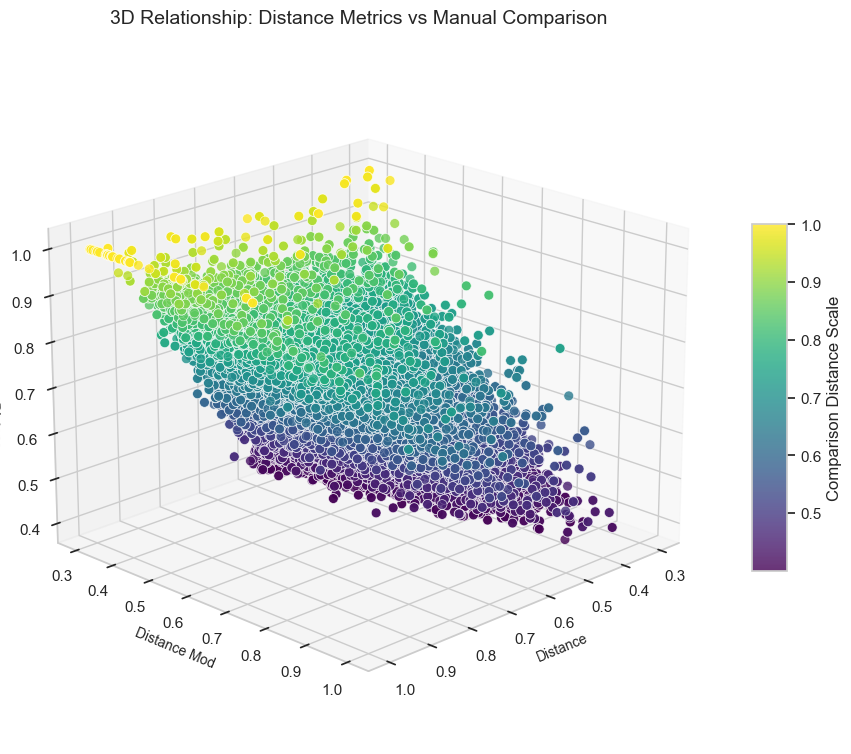

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Create the figure and a 3D axis
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 2. Extract data (clamped data is recommended)
x = dataset_clamped['distance']
y = dataset_clamped['distance_mod']
z = dataset_clamped['comparison_distance']

# 3. Create the 3D scatter
# We map 'z' to the color (c) as well to make depth easier to see
scatter = ax.scatter(
    x, y, z, 
    c=z, 
    cmap='viridis', 
    s=50, 
    alpha=0.8, 
    edgecolors='white', 
    linewidth=0.5
)

# 4. Add labels and aesthetics
ax.set_xlabel('Distance', fontsize=10)
ax.set_ylabel('Distance Mod', fontsize=10)
ax.set_zlabel('Comparison Distance', fontsize=10)
ax.set_title('3D Relationship: Distance Metrics vs Manual Comparison', fontsize=14, pad=20)

# 5. Add a color bar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Comparison Distance Scale')

# 6. Adjust the viewing angle (optional)
# Elevation of 20 degrees, Azimuth of 45 degrees
ax.view_init(elev=20, azim=45)

plt.show()


Running Grid Search...
Test size: 0.1. # of estimators: 10
Test size: 0.1. # of estimators: 50
Test size: 0.5. # of estimators: 10
Test size: 0.5. # of estimators: 50

BEST PARAMETERS FOUND
Best Training Portion: 90.0%
Best n_estimators:     50
Max R2 Score:          0.8230


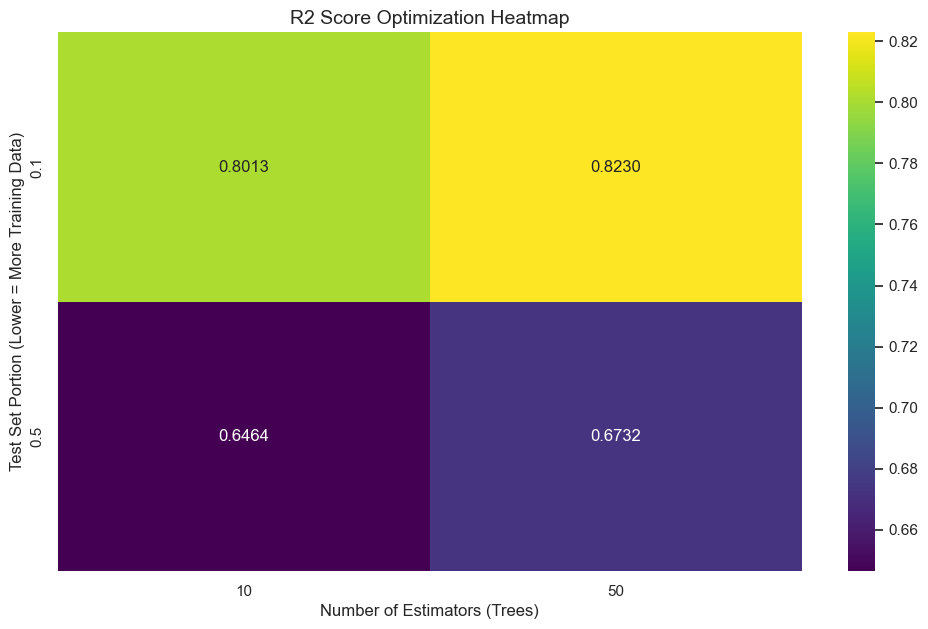

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the parameters to test
# We'll test different portions of data for testing (10% to 40%)
# and different numbers of trees in the forest
X = dataset[['distance', 'distance_mod']]
y = dataset['comparison_distance']
test_sizes = [0.1, 0.5]
n_estimators_variants = [10, 50]

tuning_results = []

print("Running Grid Search...")

# 2. Iterate through combinations
for test_size in test_sizes:
    for n_est in n_estimators_variants:
        # Split the data based on current test_size
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        
        # Train model with current n_estimators
        model = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        # Evaluate
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        
        tuning_results.append({
            'test_size': test_size,
            'train_portion': 1 - test_size,
            'n_estimators': n_est,
            'r2_score': r2
        })
        print(f"Test size: {test_size}. # of estimators: {n_est}")

# 3. Process results into a DataFrame
df_tuning = pd.DataFrame(tuning_results)

# 4. Find the best combination
best_config = df_tuning.loc[df_tuning['r2_score'].idxmax()]

print("\n" + "="*30)
print("BEST PARAMETERS FOUND")
print("="*30)
print(f"Best Training Portion: {best_config['train_portion']:.1%}")
print(f"Best n_estimators:     {int(best_config['n_estimators'])}")
print(f"Max R2 Score:          {best_config['r2_score']:.4f}")
print("="*30)

# 5. Visualize the Tuning Results with a Heatmap
pivot_r2 = df_tuning.pivot(index='test_size', columns='n_estimators', values='r2_score')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_r2, annot=True, cmap='viridis', fmt='.4f')
plt.title('R2 Score Optimization Heatmap', fontsize=14)
plt.ylabel('Test Set Portion (Lower = More Training Data)')
plt.xlabel('Number of Estimators (Trees)')
plt.show()


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Prepare features and target from your labeled 'dataset'
X_labeled = dataset[['distance', 'distance_mod']]
y_labeled = dataset['comparison_distance']

# 2. Split the labeled dataset to use 90% for training
# Note: We discard the 10% test split here because our goal is to 
# "label" the separate test_data (the full matrix).
X_train, _, y_train, _ = train_test_split(
    X_labeled, y_labeled, train_size=0.90, random_state=42
)

# 3. Initialize and train the Random Forest
# Using 50 estimators as requested
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict values for the full 'test_data' matrix
# Assuming test_data contains 'distance' and 'distance_mod'
# We'll use .copy() to avoid SettingWithCopy warnings
test_data_labeled = test_data.copy()
X_test_matrix = test_data[['distance', 'distance_mod']]

predictions = rf_model.predict(X_test_matrix)

# 5. Add the labels and export to CSV
test_data_labeled['predicted_comparison_distance'] = predictions
test_data_labeled.to_csv('test_data_label.csv', index=False)

print(f"Successfully trained on {len(X_train)} samples.")
print(f"Labeled {len(test_data_labeled)} rows in test_data.")
print("Results exported to 'test_data_label.csv'")


Successfully trained on 786075 samples.
Labeled 2177144 rows in test_data.
Results exported to 'test_data_label.csv'
